# Tech Portfolio Performance Analysis

#### Project Overview:

This project constructs and analyzes an equally-weighted portfolio of major tech stocks Apple, Microsoft, Amazon, and NVIDIA from 2000-present. Using Python, I retrieved historical price data, calculated individual and portfolio-level returns, and visualized long-term performance trends.

In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'NVDA']
mydata = pd.DataFrame()
for t in tickers:
    mydata[t] = yf.download(t, start='2000-1-1')['Close']

/var/folders/5z/fg7pl2ns0wl97dgng8q03h700000gn/T/ipykernel_39482/2675541458.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5z/fg7pl2ns0wl97dgng8q03h700000gn/T/ipykernel_39482/2675541458.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5z/fg7pl2ns0wl97dgng8q03h700000gn/T/ipykernel_39482/2675541458.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5z/fg7pl2ns0wl97dgng8q03h700000gn/T/ipykernel_39482/2675541458.py:4: FutureWarning: YF.download() has changed argument auto_adjust d

In [3]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6643 entries, 2000-01-03 to 2026-06-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    6643 non-null   float64
 1   MSFT    6643 non-null   float64
 2   AMZN    6643 non-null   float64
 3   NVDA    6643 non-null   float64
dtypes: float64(4)
memory usage: 259.5 KB


In [4]:
mydata.head()

,AAPL,MSFT,AMZN,NVDA
Date,,,,
2000-01-03,0.837724,35.443630,4.468750,0.089410
2000-01-04,0.767096,34.246323,4.096875,0.087023
2000-01-05,0.778321,34.607414,3.487500,0.084158
2000-01-06,0.710966,33.448120,3.278125,0.078667
2000-01-07,0.744644,33.885235,3.478125,0.079980


In [5]:
mydata.tail()

,AAPL,MSFT,AMZN,NVDA
Date,,,,
2026-05-27,310.850006,412.670013,271.850006,212.600006
2026-05-28,312.510010,426.989990,274.000000,214.250000
2026-05-29,312.059998,450.239990,270.640015,211.139999
2026-06-01,306.309998,460.519989,261.260010,224.360001
2026-06-02,315.200012,441.309998,256.519989,222.820007


In [6]:
mydata.iloc[0]

AAPL     0.837724
MSFT    35.443630
AMZN     4.468750
NVDA     0.089410
Name: 2000-01-03 00:00:00, dtype: float64

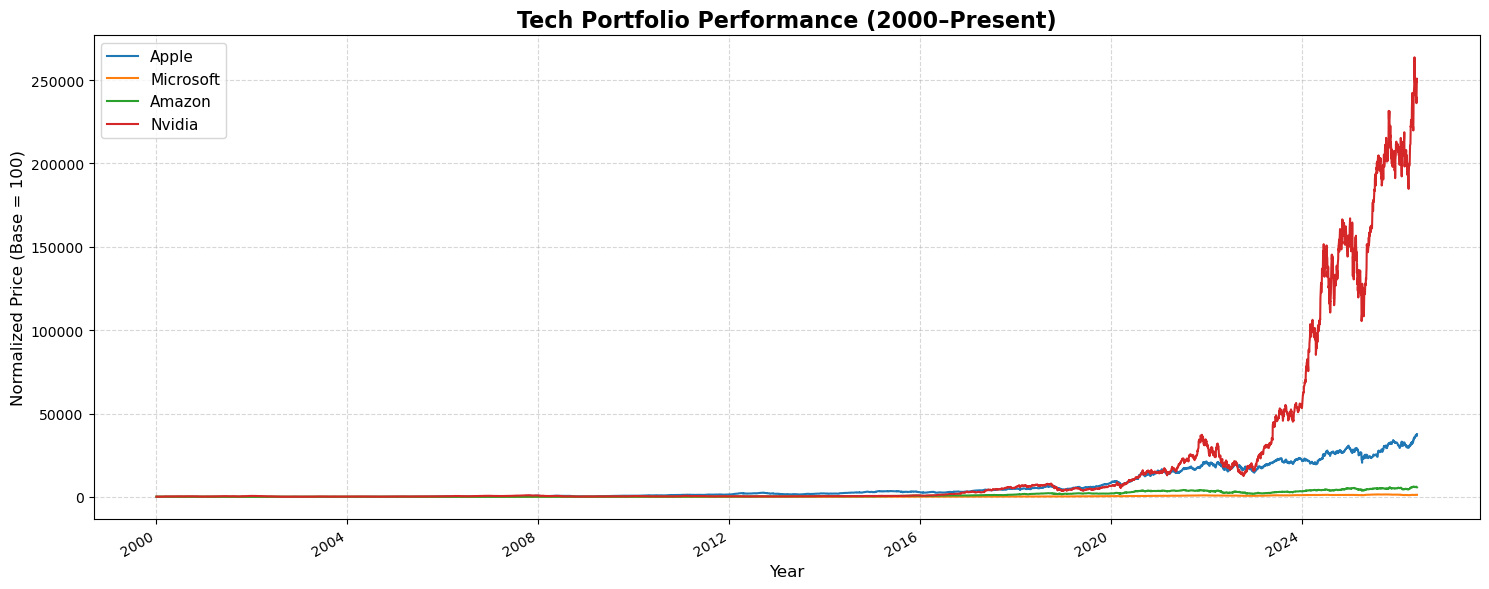

In [7]:
ax = (mydata / mydata.iloc[0] * 100).plot(figsize=(15, 6), linewidth=1.5)

ax.set_title('Tech Portfolio Performance (2000–Present)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
ax.legend(['Apple', 'Microsoft', 'Amazon', 'Nvidia'], fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
returns = (mydata / mydata.shift(1)) - 1
returns.head()

,AAPL,MSFT,AMZN,NVDA
Date,,,,
2000-01-03,NaN,NaN,NaN,NaN
2000-01-04,-0.084310,-0.033781,-0.083217,-0.026700
2000-01-05,0.014633,0.010544,-0.148741,-0.032922
2000-01-06,-0.086538,-0.033498,-0.060036,-0.065253
2000-01-07,0.047369,0.013068,0.061010,0.016701


In [9]:
weights = np.array([0.25, 0.25, 0.25, 0.25])
annual_returns = returns.mean() * 250

In [10]:
print("Individual Annual Returns:")
print(annual_returns)

Individual Annual Returns:
AAPL    0.299077
MSFT    0.139716
AMZN    0.267891
NVDA    0.464772
dtype: float64


In [11]:
np.dot(annual_returns, weights)

np.float64(0.29286409401916524)

In [12]:
pfolio_1 = str(round(np.dot(annual_returns, weights), 4) * 100) + ' %'
print(f"Equal-Weighted Portfolio Annual Return: {pfolio_1}")

Equal-Weighted Portfolio Annual Return: 29.29 %
